# Statistical and Multivariate Analysis

The exploratory data analysis identified several relationships between customer characteristics, service-related features, and churn.

The purpose of this notebook is to investigate these relationships in greater depth. First, correlations between numerical features will be examined. Then, selected multivariate relationships will be analyzed to determine whether some patterns observed during EDA may be explained by interactions between multiple customer characteristics.

Finally, statistical tests will be used to evaluate whether the observed differences are statistically significant and practically meaningful.

### Note 
The analyses in this notebook are exploratory and are performed on the full cleaned dataset to understand its structure and relationships. Data-driven feature selection decisions used for model development are performed separately using the training data only.

In [1]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
import seaborn as sns

df = pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")

## 1. Correlation Analysis

The purpose of the correlation analysis is to examine relationships between numerical features and identify variables that may contain similar information.

In [2]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

df[numeric_features].describe()

,Tenure Months,Monthly Charges,Total Charges,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,4400.295755
std,24.559481,30.090047,2266.794470,1183.057152
min,0.000000,18.250000,0.000000,2003.000000
25%,9.000000,35.500000,398.550000,3469.000000
50%,29.000000,70.350000,1394.550000,4527.000000
75%,55.000000,89.850000,3786.600000,5380.500000
max,72.000000,118.750000,8684.800000,6500.000000


Total Charges shows the strongest indication of a right-skewed distribution, with the mean substantially exceeding the median. The remaining numerical variables have means and medians that are relatively close, although this alone is not sufficient to assume normality. The variables also differ substantially in their scale and variability.

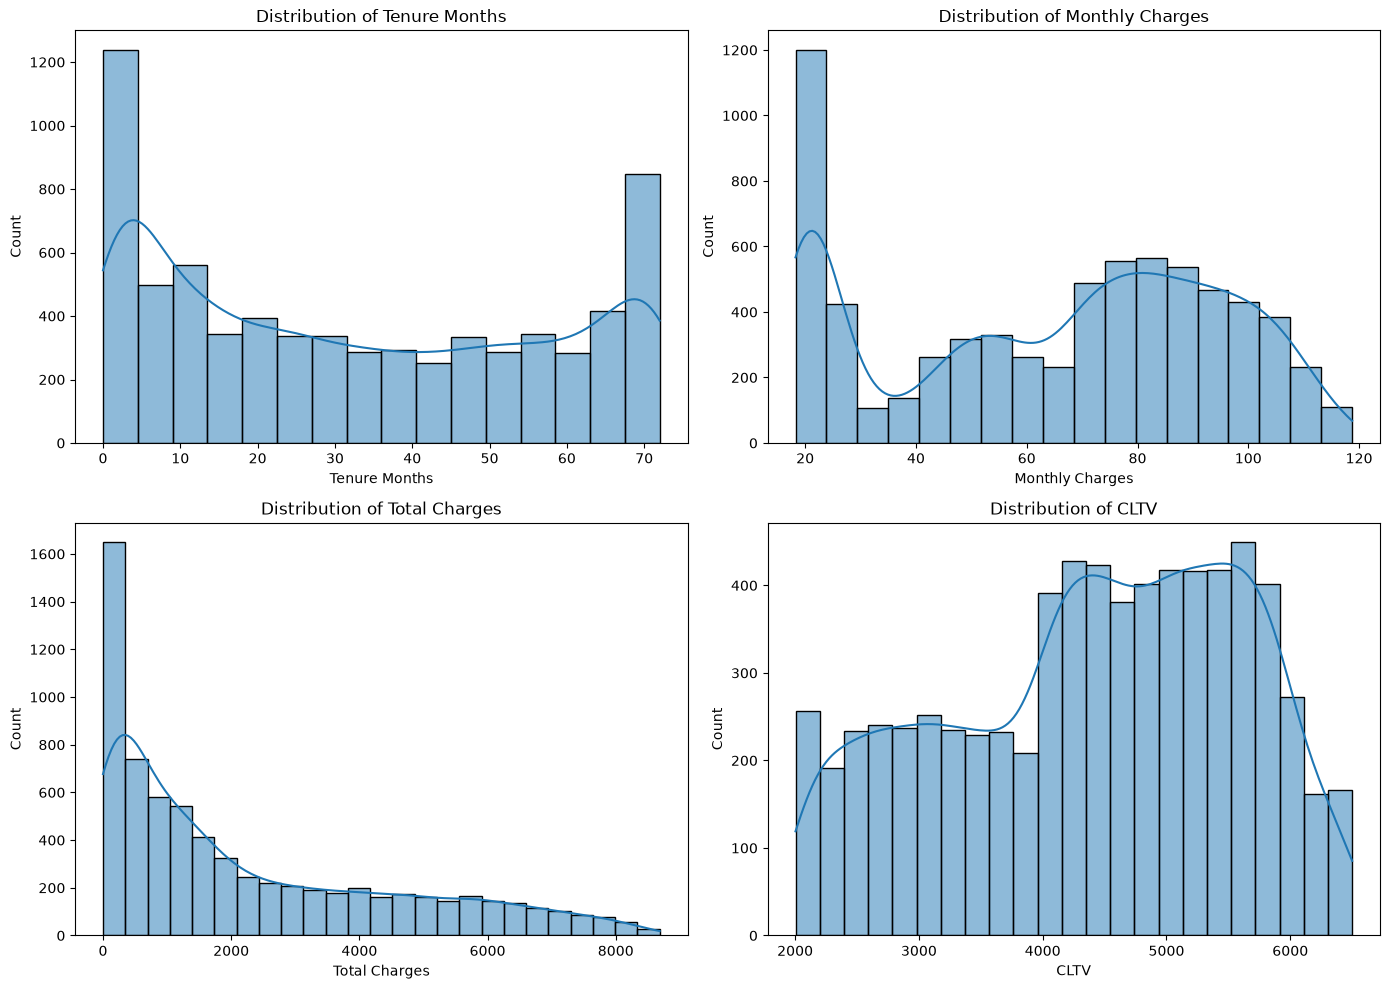

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    data=df,
    x="Tenure Months",
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Distribution of Tenure Months")

sns.histplot(
    data=df,
    x="Monthly Charges",
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Distribution of Monthly Charges")

sns.histplot(
    data=df,
    x="Total Charges",
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Distribution of Total Charges")

sns.histplot(
    data=df,
    x="CLTV",
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Distribution of CLTV")

plt.tight_layout()
plt.show()

The charts show that none of the numerical features follows an approximately normal distribution. Tenure Months has a high concentration of customers at both ends of the range, while Monthly Charges appears to contain several distinct groups of customers. Total Charges is strongly right-skewed, and CLTV also shows a non-normal distribution.

Because of these distributional patterns, it may be useful to compare Pearson and Spearman correlation coefficients. Pearson correlation will be used to examine linear relationships, while Spearman correlation provides a rank-based measure that is less sensitive to skewed distributions and outliers.

In [4]:
pearson_corr = df[numeric_features].corr(method="pearson")
spearman_corr = df[numeric_features].corr(method="spearman")

pearson_corr

,Tenure Months,Monthly Charges,Total Charges,CLTV
Tenure Months,1.000000,0.247900,0.826178,0.396406
Monthly Charges,0.247900,1.000000,0.651174,0.098693
Total Charges,0.826178,0.651174,1.000000,0.342091
CLTV,0.396406,0.098693,0.342091,1.000000


In [5]:
spearman_corr

,Tenure Months,Monthly Charges,Total Charges,CLTV
Tenure Months,1.000000,0.276417,0.889696,0.367039
Monthly Charges,0.276417,1.000000,0.638028,0.107944
Total Charges,0.889696,0.638028,1.000000,0.310721
CLTV,0.367039,0.107944,0.310721,1.000000


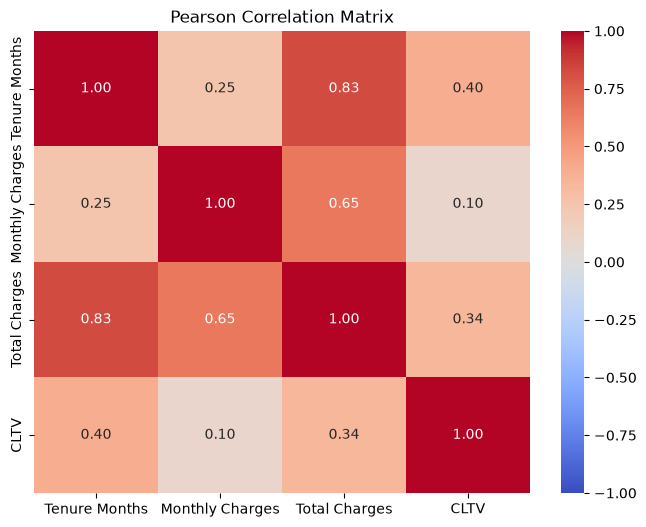

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()

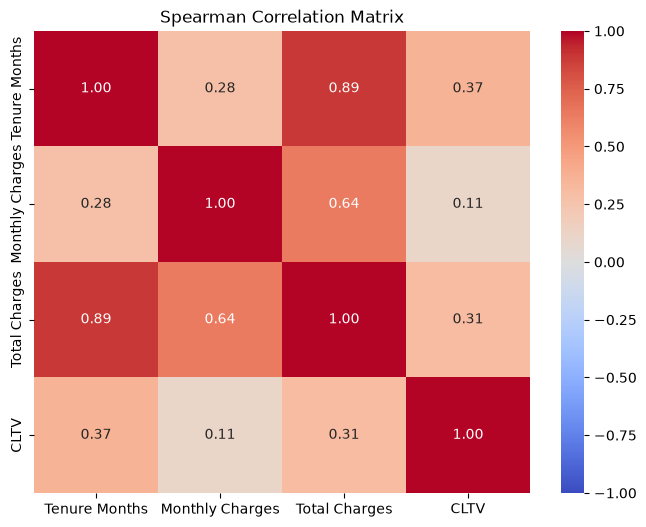

In [7]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Spearman Correlation Matrix")
plt.show()

The correlation matrices show that Tenure Months and Total Charges are strongly positively correlated in both Pearson and Spearman correlation analyses.

In [8]:
df["Churn Binary"] = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

features_with_churn = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Binary"
]

df[features_with_churn].corr(method="pearson")

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Binary
Tenure Months,1.000000,0.247900,0.826178,0.396406,-0.352229
Monthly Charges,0.247900,1.000000,0.651174,0.098693,0.193356
Total Charges,0.826178,0.651174,1.000000,0.342091,-0.198324
CLTV,0.396406,0.098693,0.342091,1.000000,-0.127463
Churn Binary,-0.352229,0.193356,-0.198324,-0.127463,1.000000


In [9]:
df[features_with_churn].corr(method="spearman")

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Binary
Tenure Months,1.000000,0.276417,0.889696,0.367039,-0.367062
Monthly Charges,0.276417,1.000000,0.638028,0.107944,0.184743
Total Charges,0.889696,0.638028,1.000000,0.310721,-0.229955
CLTV,0.367039,0.107944,0.310721,1.000000,-0.123627
Churn Binary,-0.367062,0.184743,-0.229955,-0.123627,1.000000


The numerical features show only weak to moderate correlations with churn. Tenure Months has the strongest relationship, with higher tenure being associated with lower churn. However, these results suggest that churn is unlikely to be explained by any single numerical feature. The next step is therefore to investigate categorical variables and combinations of multiple customer characteristics.

## 2. Categorical Relationships

The exploratory analysis showed substantial differences in churn rates across several categorical features. In this section, we evaluate whether these relationships are statistically significant and how strong the associations are.

In [10]:
categorical_features = [
    "Contract",
    "Internet Service",
    "Tech Support",
    "Online Security",
    "Payment Method",
    "Partner",
    "Dependents"
]

In [11]:
def categorical_association(feature, target="Churn Label"):
    contingency_table = pd.crosstab(
        df[feature],
        df[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(k - 1, r - 1))
    )

    return {
        "Feature": feature,
        "Chi-square": chi2,
        "p-value": p_value,
        "Cramér's V": cramers_v
    }

categorical_features = [
    "Contract",
    "Internet Service",
    "Tech Support",
    "Online Security",
    "Payment Method",
    "Partner",
    "Dependents"
]

In [12]:
results = [
    categorical_association(feature)
    for feature in categorical_features
]

association_results = pd.DataFrame(results)

association_results = (
    association_results
    .sort_values("Cramér's V", ascending=False)
    .reset_index(drop=True)
)

association_results


,Feature,Chi-square,p-value,Cramér's V
0,Contract,1184.596572,5.863038e-258,0.410116
1,Online Security,849.998968,2.661150e-185,0.347400
2,Tech Support,828.197068,1.443084e-180,0.342916
3,Internet Service,732.309590,9.571788e-160,0.322455
4,Payment Method,648.142327,3.682355e-140,0.303359
5,Dependents,433.734379,2.500972e-96,0.248161
6,Partner,158.733382,2.139911e-36,0.150126


Among the selected categorical features, Contract shows the strongest association with customer churn. Online Security, Tech Support, and Internet Service also show moderately strong associations with churn. Payment Method and Dependents show weaker but still noticeable relationships, while Partner has the weakest association among the analyzed categorical features (Cramér’s V ≈ 0.15). All tested relationships are statistically significant.

## 3. Multivariate Analysis

Several features showed similar churn patterns during the exploratory analysis. Therefore, the purpose of the multivariate analysis is to determine whether these features provide redundant information or whether they contribute additional information beyond other customer characteristics.

Let's start with Contract × Internet Service × Churn combination

In [13]:
contract_internet_churn = (
    df.groupby(["Contract", "Internet Service"])["Churn Binary"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

contract_internet_churn

,Contract,Internet Service,Churn Rate
0,Month-to-month,DSL,32.215863
1,Month-to-month,Fiber optic,54.605263
2,Month-to-month,No,18.893130
3,One year,DSL,9.298246
4,One year,Fiber optic,19.294991
5,One year,No,2.472527
6,Two year,DSL,1.910828
7,Two year,Fiber optic,7.226107
8,Two year,No,0.783699


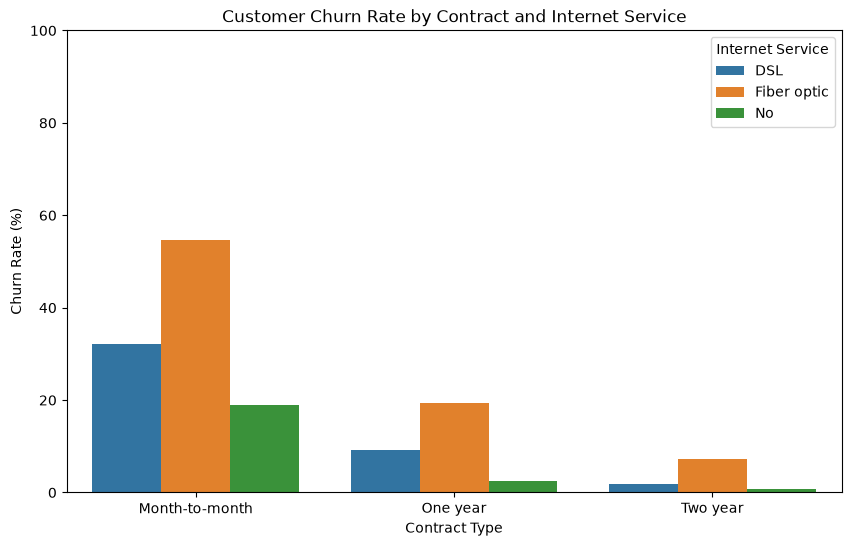

In [14]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=contract_internet_churn,
    x="Contract",
    y="Churn Rate",
    hue="Internet Service"
)

ax.set_title("Customer Churn Rate by Contract and Internet Service")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

plt.legend(title="Internet Service")
plt.show()

The results suggest that Internet Service is not fully redundant with Contract. Even within the same contract type, churn rates differ substantially across internet service categories. This indicates that Internet Service may provide additional information about churn beyond what is already captured by Contract.

Now let's try Internet Service × Tech Support × Churn combination.

In [15]:
internet_support_churn = (
    df.groupby(["Internet Service", "Tech Support"])["Churn Binary"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

internet_support_churn

,Internet Service,Tech Support,Churn Rate
0,DSL,No,27.755430
1,DSL,Yes,9.677419
2,Fiber optic,No,49.372197
3,Fiber optic,Yes,22.632794
4,No,No internet service,7.404980


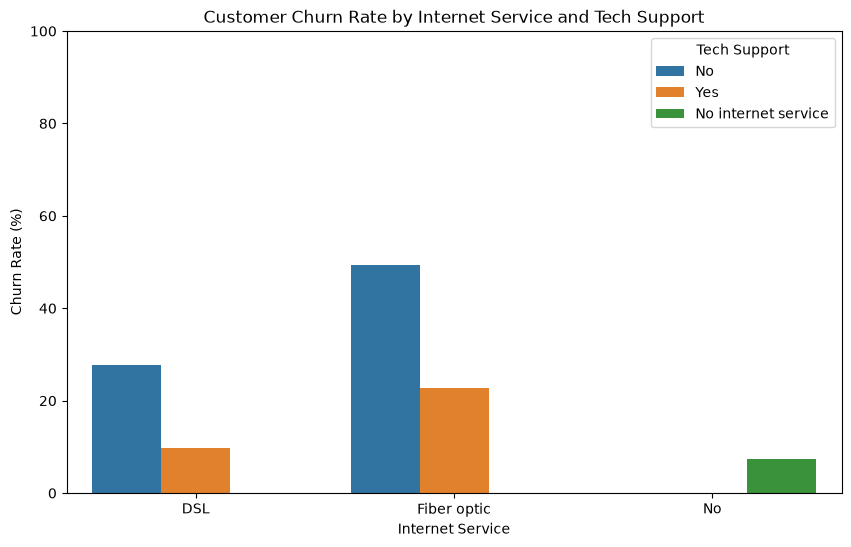

In [16]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=internet_support_churn,
    x="Internet Service",
    y="Churn Rate",
    hue="Tech Support"
)

ax.set_title("Customer Churn Rate by Internet Service and Tech Support")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

plt.legend(title="Tech Support")
plt.show()

Tech Support provides additional information beyond Internet Service, as customers without Tech Support show higher churn rates within both DSL and Fiber optic groups. The difference is especially pronounced among Fiber optic customers, suggesting a possible interaction between Internet Service and Tech Support.

Now we can try Internet Service × Online Security × Churn combination.

In [17]:
internet_security_churn = (
    df.groupby(["Internet Service", "Online Security"])["Churn Binary"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

internet_security_churn

,Internet Service,Online Security,Churn Rate
0,DSL,No,27.961322
1,DSL,Yes,9.491525
2,Fiber optic,No,49.357554
3,Fiber optic,Yes,21.811681
4,No,No internet service,7.404980


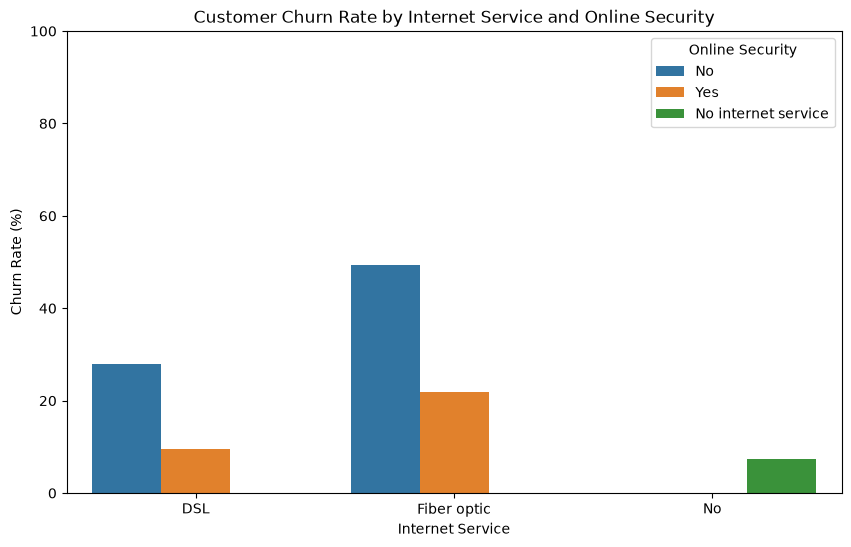

In [18]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=internet_security_churn,
    x="Internet Service",
    y="Churn Rate",
    hue="Online Security"
)

ax.set_title("Customer Churn Rate by Internet Service and Online Security")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

plt.legend(title="Online Security")
plt.show()

The churn pattern by Online Security is very similar to the pattern previously observed for Tech Support. In both cases, customers without the additional service show substantially higher churn rates for both DSL and Fiber optic connections. Because these two features produce very similar churn patterns, it is important to investigate whether they provide distinct information or whether they are partially redundant.

In [19]:
online_security_tech_support = (
    pd.crosstab(
        df["Online Security"],
        df["Tech Support"],
        normalize="index"
    )
    .mul(100)
    .reset_index()
)

online_security_tech_support

Tech Support,Online Security,No,No internet service,Yes
0,No,72.984563,0.0,27.015437
1,No internet service,0.000000,100.0,0.000000
2,Yes,45.567112,0.0,54.432888


In [20]:
online_security_tech_support_long = online_security_tech_support.melt(
    id_vars="Online Security",
    var_name="Tech Support",
    value_name="Percentage"
)

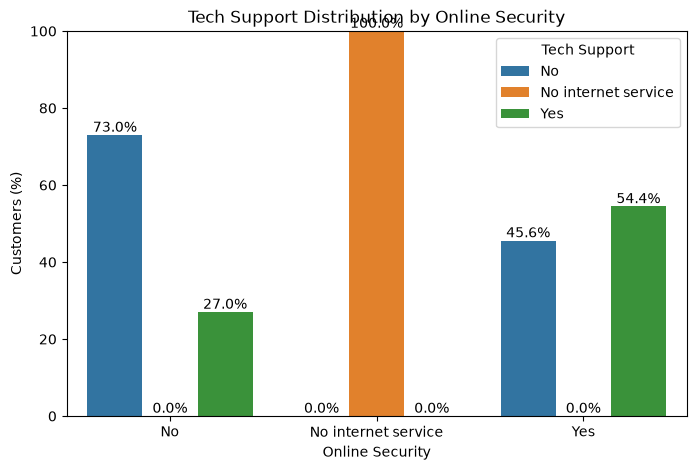

In [21]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=online_security_tech_support_long,
    x="Online Security",
    y="Percentage",
    hue="Tech Support"
)

ax.set_title("Tech Support Distribution by Online Security")
ax.set_xlabel("Online Security")
ax.set_ylabel("Customers (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Online Security and Tech Support are related, but they are not fully redundant. Customers without Online Security are more likely to also be without Tech Support, while customers with Online Security are split more evenly between having and not having Tech Support. This suggests that the two features capture overlapping, but not identical, information. Therefore, both features may still provide useful information for churn prediction.

The final combination analyzed is Payment Method × Internet Service × Churn. This is interesting because the EDA showed that customers using Electronic check had a particularly high churn rate.

In [22]:
payment_contract_churn = (
    df.groupby(["Payment Method", "Contract"])["Churn Binary"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

payment_contract_churn

,Payment Method,Contract,Churn Rate
0,Bank transfer (automatic),Month-to-month,34.125637
1,Bank transfer (automatic),One year,9.718670
2,Bank transfer (automatic),Two year,3.368794
3,Credit card (automatic),Month-to-month,32.780847
4,Credit card (automatic),One year,10.301508
5,Credit card (automatic),Two year,2.237522
6,Electronic check,Month-to-month,53.729730
7,Electronic check,One year,18.443804
8,Electronic check,Two year,7.738095
9,Mailed check,Month-to-month,31.578947


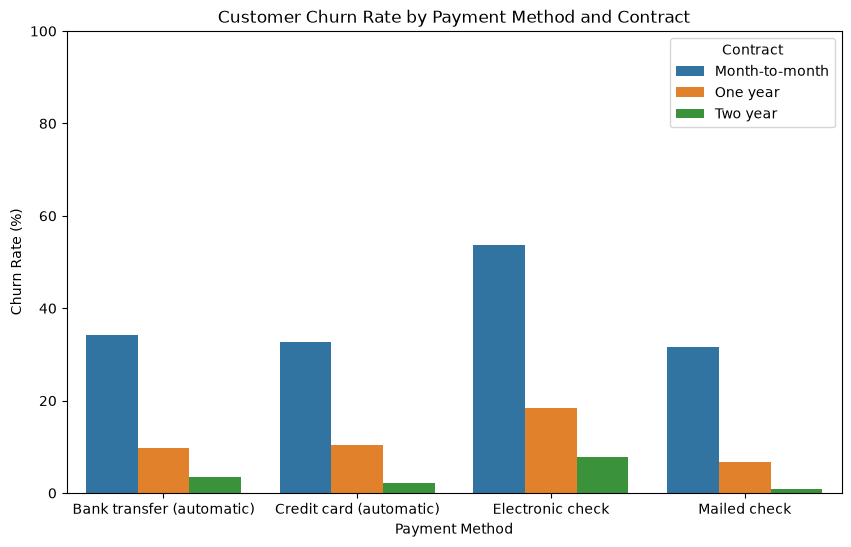

In [23]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=payment_contract_churn,
    x="Payment Method",
    y="Churn Rate",
    hue="Contract"
)

ax.set_title("Customer Churn Rate by Payment Method and Contract")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

plt.legend(title="Contract")
plt.show()

The results show that contract type has a strong relationship with churn across all payment methods, with Month-to-month customers consistently showing the highest churn rates. However, Electronic check customers also show higher churn rates within the same contract categories compared with other payment methods. This suggests that the association between Electronic check and churn cannot be explained by contract type alone, and Payment Method may provide additional information for churn prediction.

### Multivariate Findings

Although some features showed similar churn patterns, the multivariate analyses did not reveal complete redundancy among the examined variables. In most cases, churn rates still differed within the same category of another feature, suggesting that the variables capture overlapping but distinct information.

## 4. Statistical Significance Analysis

The previous analyses identified several differences between churned and non-churned customers. However, descriptive differences alone do not tell us whether the observed patterns are likely to reflect real differences or whether they could have occurred by chance in this sample.

In this section, statistical tests are used to evaluate the significance and magnitude of these differences. For numerical features, churned and non-churned customers are compared using Welch’s t-test, while Cohen’s d is used to quantify the size of the observed effect.

In [24]:
def numerical_feature_test(feature, target="Churn Label"):
    churned = df.loc[df[target] == "Yes", feature]
    not_churned = df.loc[df[target] == "No", feature]

    # Welch's t-test
    t_stat, p_value = ttest_ind(
        churned,
        not_churned,
        equal_var=False
    )

    # Means
    mean_churned = churned.mean()
    mean_not_churned = not_churned.mean()

    # Standard deviations
    std_churned = churned.std(ddof=1)
    std_not_churned = not_churned.std(ddof=1)

    # Sample sizes
    n_churned = len(churned)
    n_not_churned = len(not_churned)

    # Pooled standard deviation for Cohen's d
    pooled_std = np.sqrt(
        (
            (n_churned - 1) * std_churned**2
            + (n_not_churned - 1) * std_not_churned**2
        )
        / (n_churned + n_not_churned - 2)
    )

    cohens_d = (mean_churned - mean_not_churned) / pooled_std

    return {
        "Feature": feature,
        "Mean Churned": mean_churned,
        "Mean Not Churned": mean_not_churned,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Cohen's d": cohens_d
    }

In [25]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

results = [
    numerical_feature_test(feature)
    for feature in numeric_features
]

numerical_results = pd.DataFrame(results)

numerical_results["Absolute Cohen's d"] = numerical_results["Cohen's d"].abs()

numerical_results = (
    numerical_results
    .sort_values("Absolute Cohen's d", ascending=False)
    .reset_index(drop=True)
)

numerical_results

,Feature,Mean Churned,Mean Not Churned,t-statistic,p-value,Cohen's d,Absolute Cohen's d
0,Tenure Months,17.979133,37.569965,-34.823819,1.195495e-232,-0.852250,0.852250
1,Total Charges,1531.796094,2549.911442,-18.706618,5.902581e-75,-0.458213,0.458213
2,Monthly Charges,74.441332,61.265124,18.407527,8.592449e-73,0.446283,0.446283
3,CLTV,4149.414660,4490.921337,-10.690830,3.048903e-26,-0.291018,0.291018


All analyzed numerical features show statistically significant differences between churned and non-churned customers. Tenure Months has the largest effect size, indicating a substantial difference between the two groups. Total Charges and Monthly Charges show moderate effects, while CLTV has a weaker effect. These results suggest that Tenure Months is the strongest numerical candidate among the analyzed features for predicting customer churn.

## 5. Outlier Analysis

In [26]:
def analyze_outliers(df, features):
    results = []

    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_mask = (
            (df[feature] < lower_bound) |
            (df[feature] > upper_bound)
        )

        outlier_count = outlier_mask.sum()
        outlier_percentage = outlier_count / len(df) * 100

        results.append({
            "Feature": feature,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outliers": outlier_count,
            "Outliers (%)": outlier_percentage
        })

    return pd.DataFrame(results)

def plot_boxplots(df, features):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(12, 8)
    )

    axes = axes.flatten()

    for ax, feature in zip(axes, features):
        sns.boxplot(
            data=df,
            x=feature,
            ax=ax
        )

        ax.set_title(feature)

    plt.tight_layout()
    plt.show()

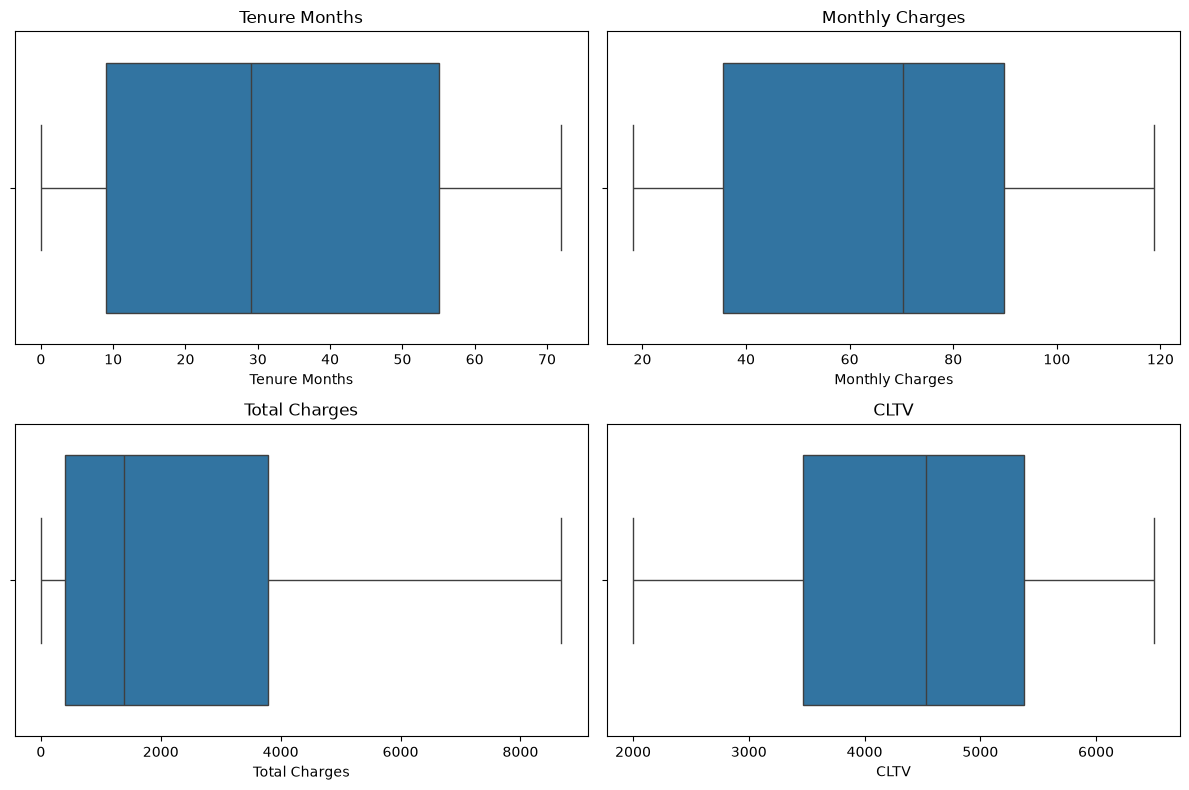

In [27]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

plot_boxplots(df, numeric_features)


In [28]:
outlier_summary = analyze_outliers(df, numeric_features)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outliers (%)
0,Tenure Months,9.00,55.00,46.00,-60.000,124.000,0,0.0
1,Monthly Charges,35.50,89.85,54.35,-46.025,171.375,0,0.0
2,Total Charges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0
3,CLTV,3469.00,5380.50,1911.50,601.750,8247.750,0,0.0


Using the 1.5 × IQR rule, no outliers were detected in the analyzed numerical features. Although some variables, particularly Total Charges, show skewed distributions and high values, these observations remain within the IQR-based outlier boundaries. Therefore, no observations need to be removed based on this criterion.

## 6. Remaining Feature Assessment

Several features were not analyzed in detail during the exploratory analysis. Before moving to model training, these remaining variables are briefly assessed to determine whether they show a meaningful association with churn and whether they should be considered as candidate predictors.

In [29]:
remaining_categorical_features = [
    "Gender",
    "Senior Citizen",
    "Phone Service",
    "Multiple Lines",
    "Online Backup",
    "Device Protection",
    "Streaming TV",
    "Streaming Movies",
    "Paperless Billing"
]

In [30]:
results = [
    categorical_association(feature)
    for feature in remaining_categorical_features
]

association_results = pd.DataFrame(results)

association_results = (
    association_results
    .sort_values("Cramér's V", ascending=False)
    .reset_index(drop=True)
)

association_results

,Feature,Chi-square,p-value,Cramér's V
0,Online Backup,601.812790,2.079759e-131,0.292316
1,Device Protection,558.419369,5.505219e-122,0.281580
2,Streaming Movies,375.661479,2.667757e-82,0.230951
3,Streaming TV,374.203943,5.528994e-82,0.230502
4,Paperless Billing,258.277649,4.073355e-58,0.191498
5,Senior Citizen,159.426300,1.510067e-36,0.150453
6,Multiple Lines,11.330441,3.464383e-03,0.040109
7,Phone Service,0.915033,3.387825e-01,0.011398
8,Gender,0.484083,4.865787e-01,0.008291


None of the remaining categorical features shows a strong association with churn. Online Backup and Device Protection have the largest effects among this group, but their associations are only moderate. Streaming-related services and Paperless Billing show weaker relationships, while Multiple Lines, Phone Service, and Gender provide little to no standalone association with churn.

Geographical variables require separate consideration. City and Zip Code have high cardinality, while Latitude and Longitude provide a numerical representation of customer location. Including all geographical variables may introduce redundant location information and increase model complexity. For the initial baseline model, these features will be excluded and can be investigated separately in a later modeling stage.

## 7. Analysis Findings

Based on the exploratory, statistical, and multivariate analyses, the following variables will be retained as candidate predictors for the initial churn model: Gender, Senior Citizen, Partner, Dependents, Tenure Months, Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Contract, Paperless Billing, Payment Method, Monthly Charges, Total Charges, and CLTV. 

Identifier, constant, geographical, and leakage-related variables were excluded. Features with weak individual associations with churn were not automatically removed, because they may still provide useful predictive information when combined with other variables.

CLTV will be retained provisionally, subject to verification that its calculation does not introduce data leakage. More generally, only features that are available at prediction time should be included in the production model.

